In [1]:
from datetime import datetime
from pathlib import Path

import torch
from torch.utils.data import DataLoader

import wandb
import h5py
from pmdd.data import MagnetismData2D
from pmdd.loss import EDMLoss, VPLoss
from pmdd.networks import EDMPrecond, VPPrecond
from pmdd.sample import sample
from pmdd.utils.calc_utils import curl_2d, div_2d
from pmdd.utils.plot_utils import plot_ddpm_sample
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

In [2]:
cfg = {
            "seed": 0,
            "epochs": 3000,
            "lr": 1e-3,
            "batch_size": 500,
            "dim": 2,
            "res": 64,
            "max": False,
            "db_name": "magfield_symm_64_30000.h5",
            "model_channels" : 16,
            "channel_mult" : [1,2],
            "num_blocks" : 1,
            "data_limit" : None
        }

device="cuda:1"

db_name = cfg["db_name"]
#print(db_name)
#print(f"/home/s214435/data/{db_name}")
db = MagnetismData2D("/home/s214435/data", cfg["db_name"], cfg["max"], norm_=False, max_observations=cfg["data_limit"])
fields = h5py.File(f"/home/s214435/data/{db_name}")
obs_load = h5py.File("/home/s214435/data/magfield_symm_64.h5")
scaling = np.std(fields["field"])

ddpm_chosen = EDMPrecond(cfg["res"], cfg["dim"], model_channels = cfg["model_channels"], 
                  channel_mult = cfg["channel_mult"], num_blocks = cfg["num_blocks"]).to(device)

In [3]:
ddpm_chosen.load_state_dict(torch.load("ddpm_layers_2_blocks_1_epoch_3000.pth", weights_only=True))

<All keys matched successfully>

In [4]:
def MAPE(gts, preds, mask=None):
    err = abs(gts - preds)
    if mask==None:
        return torch.mean(err/abs(gts))*100
    else:
        return torch.mean((err/abs(gts))*mask)*100

In [32]:
n_points_test = 100
n_obs_test= 100
data_index_test = np.random.randint(0, len(obs_load), n_points_test)
obs_torch_test = torch.tensor(np.array(obs_load["field"])[0:n_obs_test]).to(device)
mask_test=torch.zeros([1,2,64,64], device=device)
indexX = np.random.randint(0, 64, n_points_test)
indexY = np.random.randint(0, 64, n_points_test)
for i in range(n_points_test):
    mask_test[:, :, indexX[i], indexY[i]] = 1
xh_obs_test = sample(
                    ddpm_chosen,
                    n_obs_test,
                    device,
                    num_steps=200,
                    sigma=[0.002, 80],
                    rho=7,
                    pde_loss=True,
                    zeta_pde=10000,
                    obs_loss=True,
                    observations=obs_torch_test,
                    zeta_obs=100000,
                    mask=mask_test,
                    obs_scaling=scaling
                ).detach().cpu()

Generating 100 samples...


100%|██████████| 200/200 [00:15<00:00, 12.63step/s]


In [43]:
print(MAPE(obs_torch_test.detach().cpu(),xh_obs_test, mask=mask_test.detach().cpu()))
print(MAPE(obs_torch_test.detach().cpu(),xh_obs_test))
print(torch.mean((abs(obs_torch_test.detach().cpu() - xh_obs_test)/abs(obs_torch_test.detach().cpu()))*mask_test.detach().cpu()[0])*100)
print(torch.mean((abs(obs_torch_test.detach().cpu() - xh_obs_test)/abs(obs_torch_test.detach().cpu()))[:,mask_test.detach().cpu()[0]==1])*100)
print(torch.mean((torch.linalg.norm(obs_torch_test.detach().cpu() - xh_obs_test, ord=1, dim=(2,3))/torch.linalg.norm(obs_torch_test.detach().cpu(),ord=1, dim=(2,3))))*100)

print(torch.mean(torch.sum(torch.linalg.norm((obs_torch_test.detach().cpu()-xh_obs_test)*mask_test.detach().cpu(), ord=1, dim=(2,3)), dim=1)/torch.sum(torch.linalg.norm((obs_torch_test.detach().cpu())*mask_test.detach().cpu(), ord=1, dim=(2,3)), dim=1))*100)
print(torch.mean(torch.sum(torch.linalg.norm((obs_torch_test.detach().cpu()-xh_obs_test), ord=1, dim=(2,3)), dim=1)/torch.sum(torch.linalg.norm((obs_torch_test.detach().cpu()), ord=1, dim=(2,3)), dim=1))*100)

tensor(0.0049, dtype=torch.float64)
tensor(2.3146, dtype=torch.float64)
tensor(0.0049, dtype=torch.float64)
tensor(0.2029, dtype=torch.float64)
tensor(1.1115, dtype=torch.float64)
tensor(0.5905, dtype=torch.float64)
tensor(0.9624, dtype=torch.float64)


In [20]:
torch.mean(torch.linalg.norm((obs_torch_test.detach().cpu()-xh_obs_test)*mask_test.detach().cpu(), ord=1, dim=(2,3)))

tensor(0.2552, dtype=torch.float64)

In [21]:
torch.mean(torch.linalg.norm((obs_torch_test.detach().cpu()-xh_obs_test), ord=1, dim=(2,3)))

tensor(3.2481, dtype=torch.float64)

In [24]:
torch.mean(torch.linalg.norm((obs_torch_test.detach().cpu())*mask_test.detach().cpu(), ord=1, dim=(2,3)))

tensor(0.5939)

In [25]:
torch.mean(torch.linalg.norm((obs_torch_test.detach().cpu()), ord=1, dim=(2,3)))

tensor(11.3157)

In [34]:
torch.mean(torch.sum(torch.linalg.norm(((obs_torch_test.detach().cpu()-xh_obs_test))/((obs_torch_test.detach().cpu()))*mask_test.detach().cpu(), ord=1, dim=(2,3)), dim=1))

tensor(0.2886, dtype=torch.float64)

In [35]:
torch.mean(torch.sum(torch.linalg.norm(((obs_torch_test.detach().cpu()-xh_obs_test))/((obs_torch_test.detach().cpu())), ord=1, dim=(2,3)), dim=1))

tensor(89.8005, dtype=torch.float64)

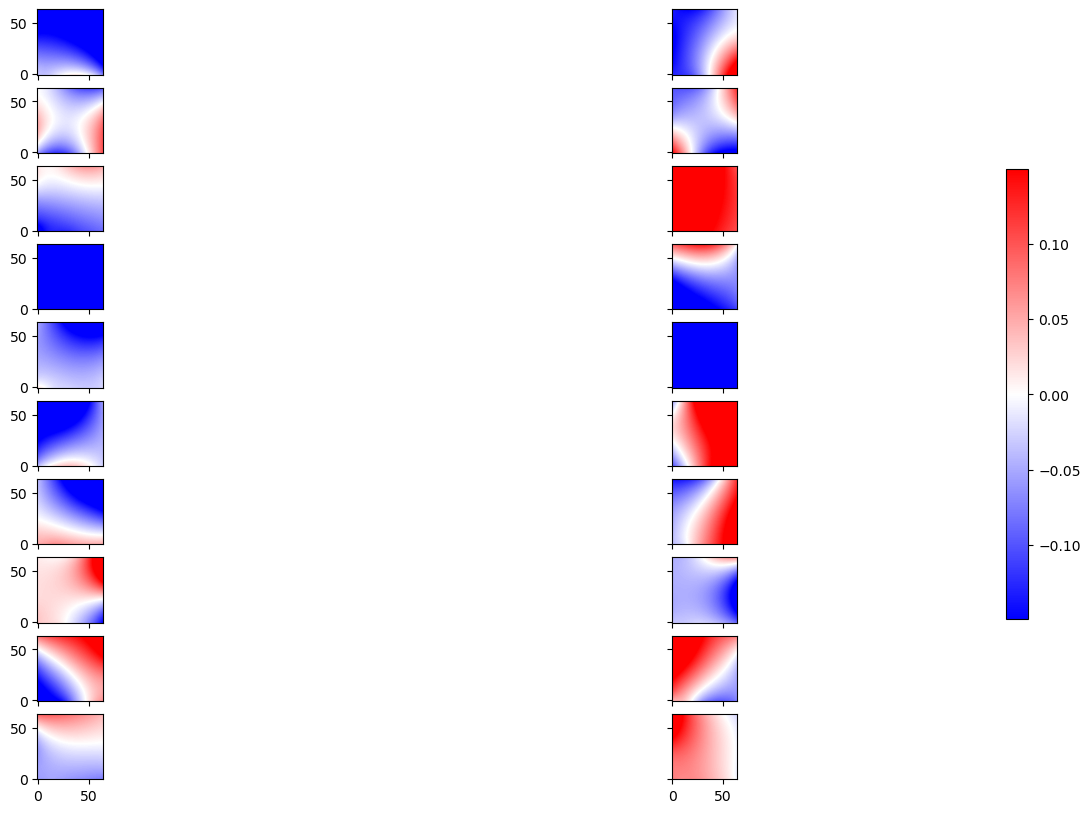

In [37]:
_ = plot_ddpm_sample(xh_obs_test[0:10], vmax=scaling)

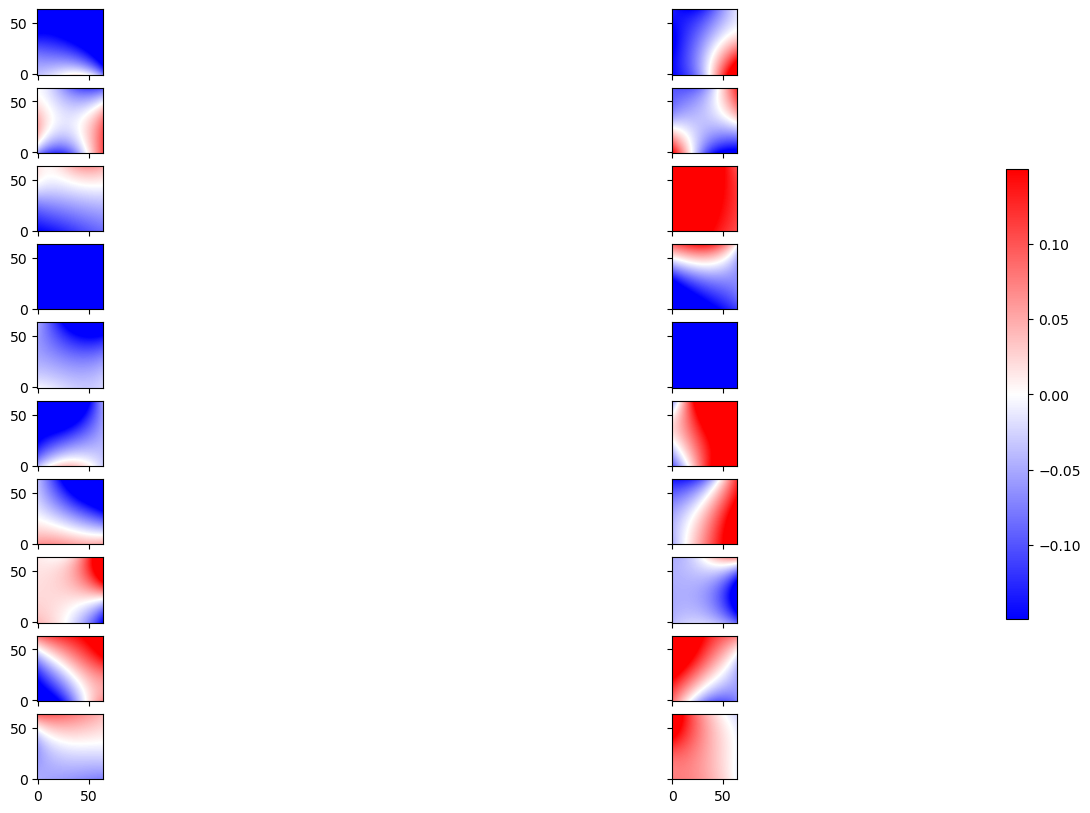

In [40]:
_ = plot_ddpm_sample(obs_torch_test.detach().cpu()[0:10], vmax=scaling)

In [41]:
print(obs_torch_test.detach().cpu()[0])

tensor([[[-0.0366, -0.0358, -0.0349,  ..., -0.0580, -0.0642, -0.0707],
         [-0.0382, -0.0375, -0.0368,  ..., -0.0676, -0.0738, -0.0803],
         [-0.0399, -0.0393, -0.0387,  ..., -0.0768, -0.0831, -0.0896],
         ...,
         [-0.1713, -0.1706, -0.1702,  ..., -0.2820, -0.2820, -0.2819],
         [-0.1696, -0.1690, -0.1687,  ..., -0.2847, -0.2847, -0.2845],
         [-0.1676, -0.1672, -0.1670,  ..., -0.2877, -0.2875, -0.2873]],

        [[-0.1472, -0.1455, -0.1437,  ...,  0.2233,  0.2330,  0.2428],
         [-0.1464, -0.1447, -0.1429,  ...,  0.2173,  0.2267,  0.2361],
         [-0.1458, -0.1440, -0.1422,  ...,  0.2112,  0.2203,  0.2295],
         ...,
         [-0.1337, -0.1352, -0.1366,  ..., -0.0195, -0.0168, -0.0142],
         [-0.1329, -0.1347, -0.1364,  ..., -0.0196, -0.0168, -0.0140],
         [-0.1323, -0.1343, -0.1363,  ..., -0.0195, -0.0166, -0.0137]]])


In [42]:
print(xh_obs_test[0])

tensor([[[-0.0326, -0.0341, -0.0351,  ..., -0.0606, -0.0675, -0.0729],
         [-0.0325, -0.0345, -0.0358,  ..., -0.0686, -0.0750, -0.0796],
         [-0.0339, -0.0351, -0.0365,  ..., -0.0774, -0.0829, -0.0887],
         ...,
         [-0.1704, -0.1696, -0.1698,  ..., -0.2819, -0.2816, -0.2823],
         [-0.1677, -0.1678, -0.1680,  ..., -0.2841, -0.2846, -0.2859],
         [-0.1656, -0.1649, -0.1661,  ..., -0.2865, -0.2854, -0.2864]],

        [[-0.1277, -0.1274, -0.1263,  ...,  0.2212,  0.2294,  0.2361],
         [-0.1295, -0.1287, -0.1274,  ...,  0.2147,  0.2229,  0.2306],
         [-0.1318, -0.1303, -0.1288,  ...,  0.2091,  0.2173,  0.2260],
         ...,
         [-0.1335, -0.1354, -0.1369,  ..., -0.0195, -0.0168, -0.0144],
         [-0.1335, -0.1358, -0.1378,  ..., -0.0193, -0.0177, -0.0155],
         [-0.1333, -0.1364, -0.1386,  ..., -0.0191, -0.0176, -0.0170]]],
       dtype=torch.float64)
